In [33]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from  load_data import load_images, load_labels
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras


In [34]:
X_T = load_images("../MNIST_dataset/train-images-idx3-ubyte/train-images-idx3-ubyte")
y_T = load_labels("../MNIST_dataset/train-labels-idx1-ubyte/train-labels-idx1-ubyte")

print("Train X shape:", X_T.shape)
print("Train y shape:", y_T.shape)
print("Sample shape:", X_T[0].shape)

Train X shape: (60000, 28, 28)
Train y shape: (60000,)
Sample shape: (28, 28)


In [35]:
#reshape to (n_samples, n_features)
X_T = X_T.reshape(X_T.shape[0], -1)

# Scale
X_T = X_T / 255.0

# One-hot encode labels
y_train_encoded = keras.utils.to_categorical(y_T, num_classes=10)


In [36]:
# Tran and val split
X_train, X_val, y_train, y_val = train_test_split(X_T, y_train_encoded, test_size=(1/6), random_state=42)
print("After split:")
print("Train X shape:", X_train.shape)
print("Train y shape:", y_train.shape)
print("Val X shape:", X_val.shape)
print("Val y shape:", y_val.shape)

After split:
Train X shape: (50000, 784)
Train y shape: (50000, 10)
Val X shape: (10000, 784)
Val y shape: (10000, 10)


In [37]:
print(f"Training set:   {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Input shape:    {X_train.shape[1]} features (28x28 pixels)")
print(f"Output shape:   {y_train.shape[1]} classes")

Training set:   50000 samples
Validation set: 10000 samples
Input shape:    784 features (28x28 pixels)
Output shape:   10 classes


In [48]:
# Create the model
learning_rates = [0.001]
hidden_layers = [(256, 128)]
batch_sizes = [8]

epochs = 50
verbose = 1

results = []
for lr in learning_rates:
    for hl in hidden_layers:
        for bs in batch_sizes:
            model = tf.keras.models.Sequential()
            model.add(tf.keras.layers.Input(shape=(784,)))
            for units in hl:
                model.add(tf.keras.layers.Dense(units, activation='relu'))
            model.add(tf.keras.layers.Dense(10, activation='softmax'))
            
            model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                          loss='categorical_crossentropy',
                          metrics=['accuracy'])
            
            history = model.fit(X_train, y_train,
                                batch_size=bs,
                                epochs=epochs,
                                validation_data=(X_val, y_val),
                                verbose=verbose)
            
            
            test_loss, test_accuracy = model.evaluate(X_val, y_val, verbose=0)
            results.append((lr, hl, bs, test_accuracy))
            print(f"LR: {lr}, Hidden: {hl}, Batch: {bs} => Test Accuracy: {test_accuracy:.4f}")

Epoch 1/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.9379 - loss: 0.2041 - val_accuracy: 0.9550 - val_loss: 0.1502
Epoch 2/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - accuracy: 0.9706 - loss: 0.0983 - val_accuracy: 0.9696 - val_loss: 0.1006
Epoch 3/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - accuracy: 0.9785 - loss: 0.0700 - val_accuracy: 0.9717 - val_loss: 0.1082
Epoch 4/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - accuracy: 0.9832 - loss: 0.0535 - val_accuracy: 0.9787 - val_loss: 0.0905
Epoch 5/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - accuracy: 0.9859 - loss: 0.0457 - val_accuracy: 0.9753 - val_loss: 0.1141
Epoch 6/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - accuracy: 0.9885 - loss: 0.0372 - val_accuracy: 0.9768 - val_loss: 0.1092
Epoch 7/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - accuracy: 0.9892 - loss: 0.0360 - val_accuracy: 0.9785 - val_loss: 0.1067
Epoch 8/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - accuracy: 0.9904 - loss: 0

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9788 - loss: 0.4977


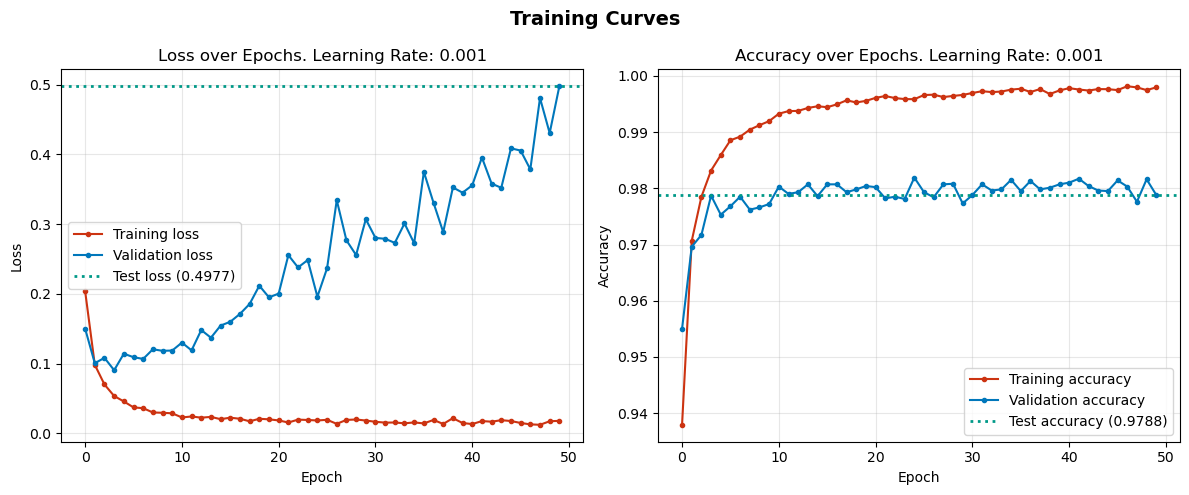

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Evaluate on test set for reference line
test_loss, test_accuracy = model.evaluate(X_val, y_val, verbose=verbose)

# Loss curves
axes[0].plot(range(epochs), history.history['loss'], 'o-', color='#CC3311', markersize=3, label='Training loss')
axes[0].plot(range(epochs), history.history['val_loss'], 'o-', color='#0077BB', markersize=3, label='Validation loss')
axes[0].axhline(y=test_loss, color='#009988', linestyle=':', linewidth=2, label=f'Test loss ({test_loss:.4f})')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title(f'Loss over Epochs. Learning Rate: {lr}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curves
axes[1].plot(range(epochs), history.history['accuracy'], 'o-', color='#CC3311', markersize=3, label='Training accuracy')
axes[1].plot(range(epochs), history.history['val_accuracy'], 'o-', color='#0077BB', markersize=3, label='Validation accuracy')
axes[1].axhline(y=test_accuracy, color='#009988', linestyle=':', linewidth=2, label=f'Test accuracy ({test_accuracy:.4f})')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title(f'Accuracy over Epochs. Learning Rate: {lr}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [50]:
# Print 10 best results
results.sort(key=lambda x: x[3], reverse=True)
for i in range(10):
    lr, hl, bs, acc = results[i]
    print(f"Rank {i+1}: LR={lr}, Hidden={hl}, Batch={bs} => Test Accuracy: {acc:.4f}")



Rank 1: LR=0.001, Hidden=(256, 128), Batch=8 => Test Accuracy: 0.9788


IndexError: list index out of range

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


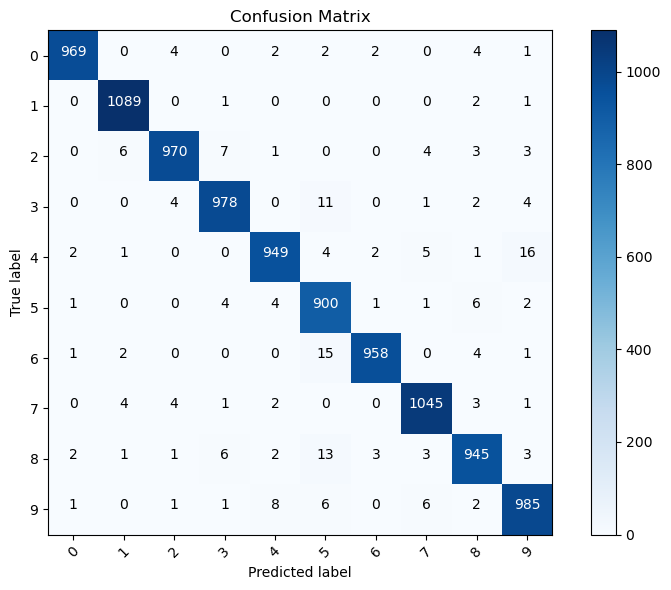

In [51]:
# Plot the confusion matrix
def plot_confusion_matrix(cm, classes, title="Confusion matrix", cmap=plt.cm.Blues):
    plt.imshow(cm, interpolation="nearest", cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = "d"
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], fmt), horizontalalignment="center", color="white" if cm[i, j] > thresh else "black")

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
y_pred = model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_val, axis=1)
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(8, 6))
plot_confusion_matrix(cm, classes=[str(i) for i in range(10)], title="Confusion Matrix")
plt.show()

In [58]:
# Load test data
X_test = load_images("../MNIST_dataset/t10k-images-idx3-ubyte/t10k-images-idx3-ubyte")
y_test = load_labels("../MNIST_dataset/t10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte")

# Preprocess test data
X_test = X_test.reshape(X_test.shape[0], -1) / 255.0
y_test_encoded = keras.utils.to_categorical(y_test, num_classes=10)
test_loss, test_accuracy = model.evaluate(X_test, y_test_encoded, verbose=0)
print(f"Final Test Accuracy on unseen test set: {test_accuracy:.4f}")


Final Test Accuracy on unseen test set: 0.9775


In [ ]:
model.summary()

Model: "sequential_54"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_182 (Dense)               │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_183 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_184 (Dense)               │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 705,440 (2.69 MB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 470,294 (1.79 MB)

In [57]:
model.save("mnist_model.keras")